In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt





In [2]:
# Load dataset
df = pd.read_csv("../data/creditcard.csv")

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


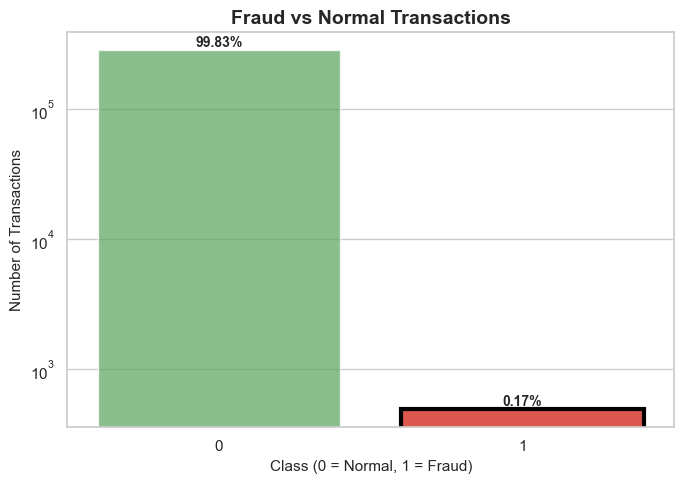

In [7]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Class',
    data=df,
    hue='Class',  
    palette={0: '#4CAF50', 1: '#F44336'},
    legend=False
)

plt.title("Fraud vs Normal Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Class (0 = Normal, 1 = Fraud)", fontsize=11)
plt.ylabel("Number of Transactions", fontsize=11)

# Percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Log scale
plt.yscale('log')


for i, bar in enumerate(ax.patches):
    if i == 1:
        bar.set_edgecolor('black')
        bar.set_linewidth(3)
    else:
        bar.set_alpha(0.7)

plt.tight_layout()
plt.show()

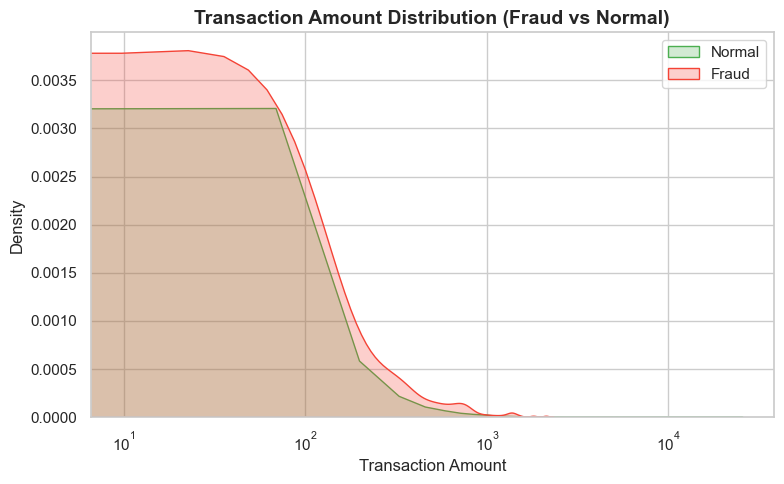

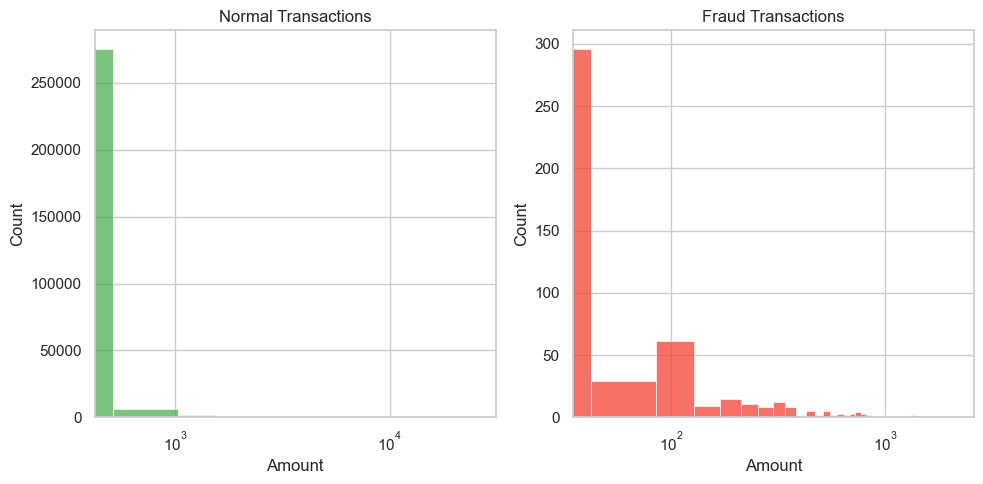

In [9]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df[df['Class']==0]['Amount'],
    label='Normal',
    color='#4CAF50',
    fill=True
)

sns.kdeplot(
    df[df['Class']==1]['Amount'],
    label='Fraud',
    color='#F44336',
    fill=True
)

plt.title("Transaction Amount Distribution (Fraud vs Normal)", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.xscale('log')

plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='#4CAF50')
plt.title("Normal Transactions")
plt.xscale('log')

plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='#F44336')
plt.title("Fraud Transactions")
plt.xscale('log')

plt.tight_layout()
plt.show()

In [10]:
corr = df.corr()['Class'].sort_values(ascending=False)
corr

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [11]:
top_pos = corr.head(6).index
top_neg = corr.tail(6).index

top_features = list(top_pos) + list(top_neg)

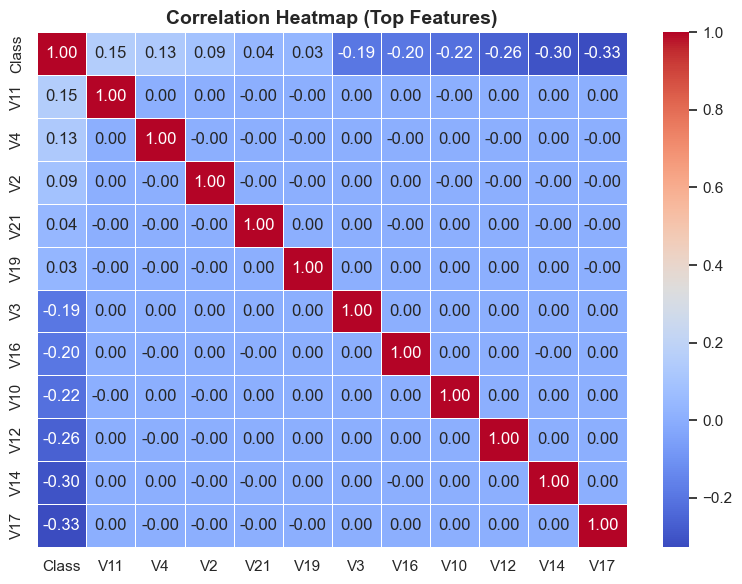

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[top_features].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Top Features)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()